# Auction algorithm iterates

This notebook generates `fig:dual-auction-progression`.  It uses the same ordered one-dimensional squared-distance assignment as the Hungarian figure.  The matrices show actual bidding states: unassigned rows remain flat, assigned rows are one-hot, and the last panel is the identity assignment.


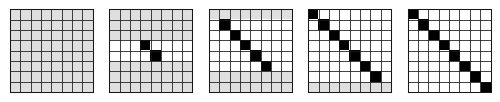

In [1]:
from pathlib import Path
import sys

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        NOTEBOOK_DIR = candidate.resolve()
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np

from figure_style import figure_dir, save_pdf, setup_matplotlib

setup_matplotlib()


def draw_matrix(ax, M):
    n = M.shape[0]
    ax.imshow(M, cmap="gray_r", vmin=0, vmax=1, interpolation="nearest")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax.grid(which="minor", color="#181818", linewidth=0.58)
    ax.tick_params(which="minor", bottom=False, left=False)
    for spine in ax.spines.values():
        spine.set_linewidth(0.75)
        spine.set_color("#181818")


def render_assignment_state(assignment):
    """Display the current auction ownership: flat unassigned rows, one-hot assigned rows."""
    n = len(assignment)
    M = np.full((n, n), 1.0 / n)
    for i, j in enumerate(assignment):
        if j >= 0:
            M[i, :] = 0.0
            M[i, j] = 1.0
    return M


def auction_snapshots(C, epsilon=5e-4):
    n = C.shape[0]
    profit = -C
    prices = np.zeros(n)
    owner = -np.ones(n, dtype=int)
    assignment = -np.ones(n, dtype=int)
    queue = [3, 4, 2, 5, 1, 6, 0, 7]
    snapshots = []

    def snapshot(t):
        snapshots.append((t, render_assignment_state(assignment.copy())))

    snapshot(0)
    t = 0
    while queue and t < 200:
        i = int(queue.pop(0))
        if assignment[i] != -1:
            continue
        reduced = profit[i] - prices
        order = np.argsort(reduced)
        j = int(order[-1])
        j_second = int(order[-2])
        bid = reduced[j] - reduced[j_second] + epsilon
        prices[j] += bid
        previous_owner = owner[j]
        owner[j] = i
        assignment[i] = j
        if previous_owner != -1:
            assignment[previous_owner] = -1
            queue.append(int(previous_owner))
        t += 1
        snapshot(t)
    if not np.all(assignment == np.arange(n)):
        raise RuntimeError(f"Auction did not recover identity assignment: {assignment}")
    return snapshots


def save_stage_panels(stages, out, thumb):
    for k, (_, M) in enumerate(stages):
        fig, ax = plt.subplots(figsize=(1.05, 1.05))
        draw_matrix(ax, M)
        save_pdf(fig, out / f"stage-{k}.pdf", pad_inches=0.012)
        plt.close(fig)
    fig, axs = plt.subplots(1, len(stages), figsize=(6.2, 1.25))
    for ax, (_, M) in zip(axs, stages):
        draw_matrix(ax, M)
    fig.savefig(thumb, dpi=230, bbox_inches="tight", pad_inches=0.02)
    plt.show()


OUT = figure_dir("dual-auction-progression")
THUMB = NOTEBOOK_DIR / "thumbnails" / "dual-auction-progression.png"
THUMB.parent.mkdir(exist_ok=True)

n = 8
x = np.linspace(-1.0, 1.0, n)
# Mild target-grid perturbations keep the identity optimum while avoiding
# misleading off-diagonal intermediate states in this pedagogical display.
y = x + np.array([-0.030, 0.015, -0.018, 0.010, -0.010, 0.018, -0.015, 0.030])
C = (x[:, None] - y[None, :]) ** 2
all_snapshots = auction_snapshots(C)
selected_indices = [0, 2, 5, 7, len(all_snapshots) - 1]
stages = [all_snapshots[k] for k in selected_indices]

save_stage_panels(stages, OUT, THUMB)
